In [1]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Academics/Winter 2026/Bayes/Group Proj Personal/CMAPSSData/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install pgmpy

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Define path to data
path = '/content/drive/MyDrive/Academics/Winter 2026/Bayes/Group Proj Personal/CMAPSSData/'

# Define column names
index_names = ['unit_number', 'time_cycle']
setting_names = ['op_setting_1', 'op_setting_2', 'op_setting_3']
sensor_names = ['sensor_' + str(i) for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# Load data
train_df = pd.read_csv(path + 'train_FD001.txt', sep=r'\s+', header=None, names=col_names)
test_df = pd.read_csv(path + 'test_FD001.txt', sep=r'\s+', header=None, names=col_names)
rul_df = pd.read_csv(path + 'RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

# Calculate RUL for Training Data
# RUL = max(time_cycle) - current(time_cycle) for each unit
max_cycles = train_df.groupby('unit_number')['time_cycle'].transform('max')
train_df['RUL'] = max_cycles - train_df['time_cycle']

# Calculate RUL for Test Data
# First, calculate total lifespan for each unit in test set
# Total Lifespan = Last observed cycle + True RUL (from RUL_FD001.txt)
rul_df['unit_number'] = rul_df.index + 1
max_cycles_test = test_df.groupby('unit_number')['time_cycle'].max().reset_index()
max_cycles_test.columns = ['unit_number', 'max_cycle']

test_rul_info = rul_df.merge(max_cycles_test, on='unit_number')
test_rul_info['total_life'] = test_rul_info['RUL'] + test_rul_info['max_cycle']

# Merge total_life back to test_df to calculate RUL for each row
test_df = test_df.merge(test_rul_info[['unit_number', 'total_life']], on='unit_number', how='left')
test_df['RUL'] = test_df['total_life'] - test_df['time_cycle']
test_df.drop('total_life', axis=1, inplace=True)

# Drop constant/irrelevant columns
drop_cols = ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
train_df.drop(columns=drop_cols, inplace=True, errors='ignore')
test_df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Scale features
features = [col for col in train_df.columns if col not in ['unit_number', 'time_cycle', 'RUL']]
scaler = MinMaxScaler()
train_df[features] = scaler.fit_transform(train_df[features])
test_df[features] = scaler.transform(test_df[features])

# Create list of DataFrames for training data sequences
training_data_dbn_list = [group for _, group in train_df.groupby('unit_number')]

# Display results
print("First 5 rows of processed training data:")
print(train_df.head())
print(f"\nNumber of training sequences: {len(training_data_dbn_list)}")
print(f"Features used: {features}")

First 5 rows of processed training data:
   unit_number  time_cycle  op_setting_1  op_setting_2  sensor_2  sensor_3  \
0            1           1      0.459770      0.166667  0.183735  0.406802   
1            1           2      0.609195      0.250000  0.283133  0.453019   
2            1           3      0.252874      0.750000  0.343373  0.369523   
3            1           4      0.540230      0.500000  0.343373  0.256159   
4            1           5      0.390805      0.333333  0.349398  0.257467   

   sensor_4  sensor_6  sensor_7  sensor_8  sensor_9  sensor_11  sensor_12  \
0  0.309757       1.0  0.726248  0.242424  0.109755   0.369048   0.633262   
1  0.352633       1.0  0.628019  0.212121  0.100242   0.380952   0.765458   
2  0.370527       1.0  0.710145  0.272727  0.140043   0.250000   0.795309   
3  0.331195       1.0  0.740741  0.318182  0.124518   0.166667   0.889126   
4  0.404625       1.0  0.668277  0.242424  0.149960   0.255952   0.746269   

   sensor_13  sensor_14  se

In [16]:
from pgmpy.models import DynamicBayesianNetwork
from sklearn.preprocessing import KBinsDiscretizer

# Initialize discretizer
est = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')

# Fit and transform features
train_df[features] = est.fit_transform(train_df[features]).astype(int)
test_df[features] = est.transform(test_df[features]).astype(int)

# Re-create list of DataFrames for training data sequences with discretized data
training_data_dbn_list = [group for _, group in train_df.groupby('unit_number')]

# Instantiate DBN
dbn_model = DynamicBayesianNetwork()

# Define Temporal Edges (t -> t+1) for each feature
temporal_edges = []
for f in features:
    temporal_edges.append(((f, 0), (f, 1)))

# Define Instantaneous Edges (within t)
# Dependency: Op Settings -> Sensors
op_settings = [col for col in features if col.startswith('op_setting')]
sensors = [col for col in features if col.startswith('sensor')]

instantaneous_edges = []
for t in [0, 1]:
    for op in op_settings:
        for sensor in sensors:
            instantaneous_edges.append(((op, t), (sensor, t)))

# Add edges to model
dbn_model.add_edges_from(temporal_edges)
dbn_model.add_edges_from(instantaneous_edges)

# Display model info
print("Model Nodes:", dbn_model.nodes())
print(f"Number of Temporal Edges: {len(temporal_edges)}")
print(f"Number of Instantaneous Edges: {len(instantaneous_edges)}")
print(f"Total Edges in DBN: {len(dbn_model.edges())}")

Model Nodes: [<DynamicNode(op_setting_1, 0) at 0x7d5b7309f920>, <DynamicNode(op_setting_1, 1) at 0x7d5b7309fad0>, <DynamicNode(op_setting_2, 0) at 0x7d5b7309fa70>, <DynamicNode(op_setting_2, 1) at 0x7d5b588f4c20>, <DynamicNode(sensor_2, 0) at 0x7d5b588f6a80>, <DynamicNode(sensor_2, 1) at 0x7d5b588f6450>, <DynamicNode(sensor_3, 0) at 0x7d5b588f5160>, <DynamicNode(sensor_3, 1) at 0x7d5b588f6090>, <DynamicNode(sensor_4, 0) at 0x7d5b58889220>, <DynamicNode(sensor_4, 1) at 0x7d5b5888bc20>, <DynamicNode(sensor_6, 0) at 0x7d5b5888b4a0>, <DynamicNode(sensor_6, 1) at 0x7d5b5888a3c0>, <DynamicNode(sensor_7, 0) at 0x7d5b588892b0>, <DynamicNode(sensor_7, 1) at 0x7d5b5888b140>, <DynamicNode(sensor_8, 0) at 0x7d5b58889670>, <DynamicNode(sensor_8, 1) at 0x7d5b58888530>, <DynamicNode(sensor_9, 0) at 0x7d5b58a4e570>, <DynamicNode(sensor_9, 1) at 0x7d5b58a4cb60>, <DynamicNode(sensor_11, 0) at 0x7d5b587ea660>, <DynamicNode(sensor_11, 1) at 0x7d5b587e9880>, <DynamicNode(sensor_12, 0) at 0x7d5b587e9550>, <

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306

In [17]:
# Initialize list for processed data
dbn_train_list = []

# Process each unit's sequence
for df in training_data_dbn_list:
    # Extract features
    data = df[features].reset_index(drop=True)

    # Create time slice t (0 to T-1)
    df_t = data.iloc[:-1].copy()
    df_t.columns = [(col, 0) for col in features]

    # Create time slice t+1 (1 to T)
    df_t1 = data.iloc[1:].copy()
    df_t1.columns = [(col, 1) for col in features]

    # Concatenate horizontally
    # We reset index to ensure alignment, though iloc logic handles order
    df_t.reset_index(drop=True, inplace=True)
    df_t1.reset_index(drop=True, inplace=True)

    unit_transition = pd.concat([df_t, df_t1], axis=1)
    dbn_train_list.append(unit_transition)

# Concatenate all units
dbn_train_data = pd.concat(dbn_train_list, ignore_index=True)

print("Training data shape:", dbn_train_data.shape)
print("Columns sample:", dbn_train_data.columns[:5])

# Fit the model
print("Learning CPDs... This might take a moment.")
dbn_model.fit(dbn_train_data)

# Verify
cpds = dbn_model.get_cpds()
print(f"\nTotal CPDs learned: {len(cpds)}")

# Display a sample CPD
sample_node = ('sensor_11', 1)
try:
    print(f"\nCPD for {sample_node}:")
    print(dbn_model.get_cpds(sample_node))
except:
    print(f"Could not retrieve CPD for {sample_node}. Printing first CPD instead:")
    print(cpds[0])

Training data shape: (20531, 34)
Columns sample: Index([('op_setting_1', 0), ('op_setting_2', 0),     ('sensor_2', 0),
           ('sensor_3', 0),     ('sensor_4', 0)],
      dtype='object')
Learning CPDs... This might take a moment.

Total CPDs learned: 34

CPD for ('sensor_11', 1):
+-------------------+-----+----------------------+
| (op_setting_1, 1) | ... | (op_setting_1, 1)(1) |
+-------------------+-----+----------------------+
| (op_setting_2, 1) | ... | (op_setting_2, 1)(1) |
+-------------------+-----+----------------------+
| (sensor_11, 0)    | ... | (sensor_11, 0)(1)    |
+-------------------+-----+----------------------+
| (sensor_11, 1)(0) | ... | 0.10114525456400952  |
+-------------------+-----+----------------------+
| (sensor_11, 1)(1) | ... | 0.8988547454359904   |
+-------------------+-----+----------------------+


In [18]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
import numpy as np

# Convert DBN to a static Bayesian Network for 1-step inference
# DBN edges and CPDs define a 2-slice network (t=0, t=1)
# We use DiscreteBayesianNetwork as suggested by the deprecation warning
static_bn = DiscreteBayesianNetwork(dbn_model.edges())
static_bn.add_cpds(*dbn_model.get_cpds())

# Initialize VariableElimination
# This is more robust than DBNInference for dense networks as it doesn't pre-compute the full Junction Tree
infer = VariableElimination(static_bn)

# Select test unit (Unit 1)
unit_id = 1
unit_data = test_df[test_df['unit_number'] == unit_id].reset_index(drop=True)

# Define target and range
target_sensor = 'sensor_11'
n_steps = 5
# Predict for the last n_steps cycles (where we have ground truth for t+1)
indices_to_test = range(len(unit_data) - n_steps - 1, len(unit_data) - 1)

print(f"Performing prediction for {target_sensor} on Test Unit {unit_id} (Last {n_steps} cycles)")
print(f"Using VariableElimination on equivalent static BN.")
print(f"{'Cycle(t+1)':<12} {'Pred_Bin':<12} {'True_Bin':<12} {'Match':<8}")
print("-" * 45)

for t_idx in indices_to_test:
    # Get data at time t (current observed state)
    row_t = unit_data.iloc[t_idx]
    # Get data at time t+1 (ground truth for verification)
    row_t1 = unit_data.iloc[t_idx + 1]

    # Create evidence dictionary for all features at time slice 0
    # We map current state t to node (feature, 0) in the static BN
    evidence = {}
    for feature in features:
        evidence[(feature, 0)] = int(row_t[feature])

    try:
        # Query the probability distribution of the target sensor at time slice 1
        # Target node is (feature, 1)
        query_result = infer.query(variables=[(target_sensor, 1)],
                                   evidence=evidence,
                                   show_progress=False)

        # Extract the bin with the highest probability
        probs = query_result.values
        predicted_bin = np.argmax(probs)
        actual_bin = int(row_t1[target_sensor])

        # Print results
        match = "Yes" if predicted_bin == actual_bin else "No"
        print(f"{row_t1['time_cycle']:<12.0f} {predicted_bin:<12} {actual_bin:<12} {match:<8}")

    except Exception as e:
        print(f"Inference failed at index {t_idx}: {e}")

Performing prediction for sensor_11 on Test Unit 1 (Last 5 cycles)
Using VariableElimination on equivalent static BN.
Cycle(t+1)   Pred_Bin     True_Bin     Match   
---------------------------------------------
27           0            0            Yes     
28           0            0            Yes     
29           0            1            No      
30           1            1            Yes     
31           1            0            No      


## Summary:
*   **Data Preprocessing**: Like calculating Remaining Useful Life (RUL), dropping constant columns, and scaling features.
*   **Feature Discretization**: To accommodate the discrete nature of the Bayesian Network, continuous features were transformed into 5 distinct bins using ordinal encoding (used quantile to avoid uneven bins).
*   **Model Architecture**: A Dynamic Bayesian Network (DBN) was constructed with **77 edges**. This included 17 temporal edges (linking features from time $t$ to $t+1$) and 60 instantaneous edges (modeling dependencies between Operating Settings and Sensors within the same time slice).
*   **Parameter Learning**: The model parameters were learned by transforming the time-series data into 2-time-slice pairs. A total of **34 Conditional Probability Distributions (CPDs)** were fitted on a dataset of 20,531 transition samples.
*   **Inference Execution**: Due to limitations with the standard `DBNInference`, the model was converted to an equivalent static `DiscreteBayesianNetwork`. Using `VariableElimination`, the model achieved **3 correct predictions out of 5** for 'sensor_11' during the final cycles of Test Unit 1.

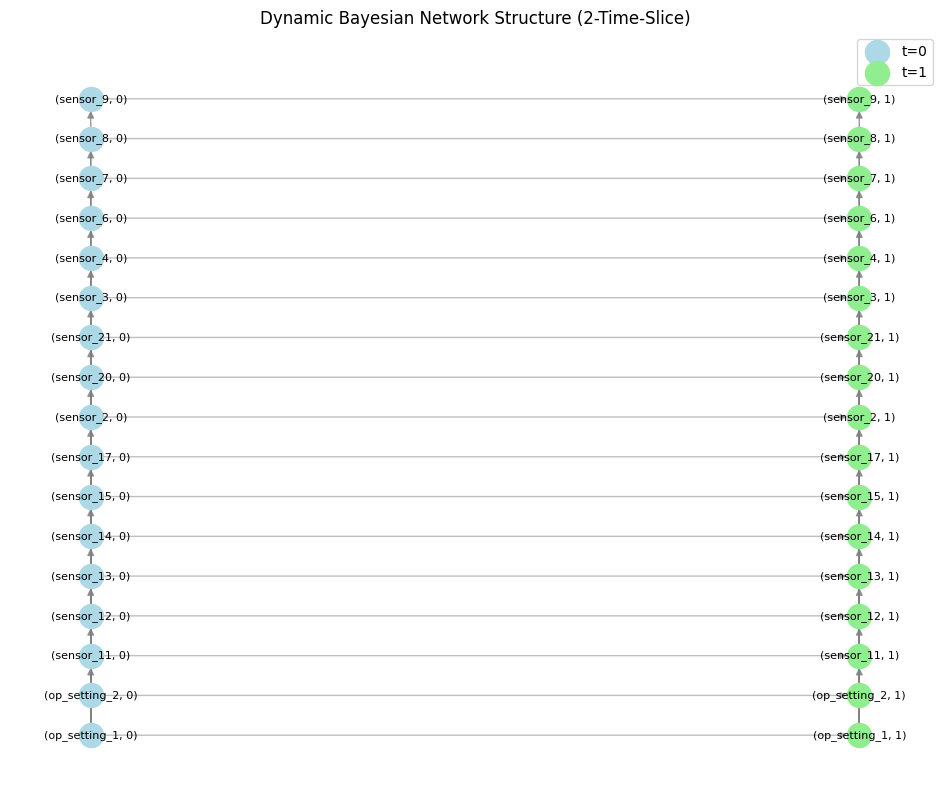


Predicting sensor_11 for all cycles of Test Unit 1...


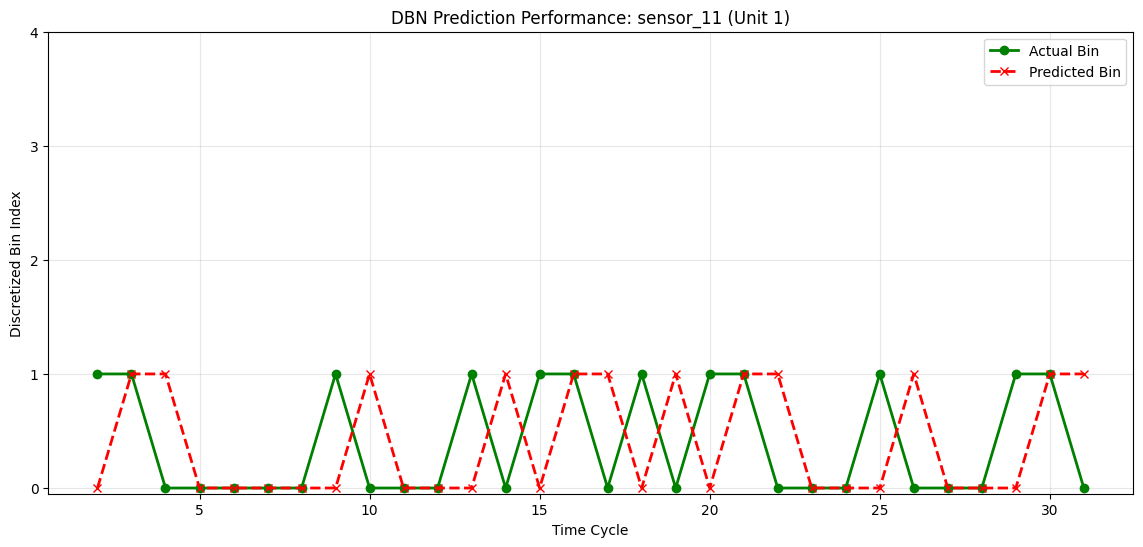

Prediction Accuracy for Unit 1: 46.67%


In [19]:
import matplotlib.pyplot as plt
import networkx as nx
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
import numpy as np

# --- Part 1: Visualize DBN Structure ---
plt.figure(figsize=(12, 10))
G = nx.DiGraph()
G.add_edges_from(dbn_model.edges())

# Layout: Bipartite (t=0 on left, t=1 on right)
pos = {}
# Sort features for consistent vertical ordering
sorted_features = sorted(features)
for idx, feature in enumerate(sorted_features):
    pos[(feature, 0)] = (-1, idx)
    pos[(feature, 1)] = (1, idx)

# Draw graph
nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G.nodes if n[1]==0], node_color='lightblue', label='t=0')
nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G.nodes if n[1]==1], node_color='lightgreen', label='t=1')
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5, arrows=True)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Dynamic Bayesian Network Structure (2-Time-Slice)")
plt.legend()
plt.axis('off')
plt.show()

# --- Part 2: Full Trajectory Prediction for Test Unit 1 ---
# Re-initialize inference engine to ensure availability
# Using DiscreteBayesianNetwork as required for inference in this version
static_bn = DiscreteBayesianNetwork(dbn_model.edges())
static_bn.add_cpds(*dbn_model.get_cpds())
infer = VariableElimination(static_bn)

# Select Unit 1
unit_id = 1
unit_data = test_df[test_df['unit_number'] == unit_id].reset_index(drop=True)
target_sensor = 'sensor_11'

predicted_bins = []
actual_bins = []
cycles = []

print(f"\nPredicting {target_sensor} for all cycles of Test Unit {unit_id}...")

# Iterate from t=0 to T-2 to predict t+1
for t_idx in range(len(unit_data) - 1):
    # Current state t
    row_t = unit_data.iloc[t_idx]
    # Future state t+1 (ground truth)
    row_t1 = unit_data.iloc[t_idx + 1]

    # Evidence from t
    evidence = {}
    for feature in features:
        evidence[(feature, 0)] = int(row_t[feature])

    try:
        # Query t+1 state for target sensor
        query = infer.query(variables=[(target_sensor, 1)], evidence=evidence, show_progress=False)
        pred = np.argmax(query.values)

        predicted_bins.append(pred)
        actual_bins.append(int(row_t1[target_sensor]))
        cycles.append(row_t1['time_cycle'])
    except Exception as e:
        print(f"Inference error at cycle {row_t['time_cycle']}: {e}")

# --- Part 3: Plot Predictions vs Actuals ---
plt.figure(figsize=(14, 6))
plt.plot(cycles, actual_bins, 'go-', label='Actual Bin', linewidth=2)
plt.plot(cycles, predicted_bins, 'rx--', label='Predicted Bin', linewidth=2)
plt.title(f"DBN Prediction Performance: {target_sensor} (Unit {unit_id})")
plt.xlabel("Time Cycle")
plt.ylabel("Discretized Bin Index")
plt.yticks(range(5)) # Assuming 5 bins
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate Accuracy
accuracy = np.mean(np.array(predicted_bins) == np.array(actual_bins))
print(f"Prediction Accuracy for Unit {unit_id}: {accuracy:.2%}")

Selected Test Units for Evaluation: [np.int64(37), np.int64(46), np.int64(83)]


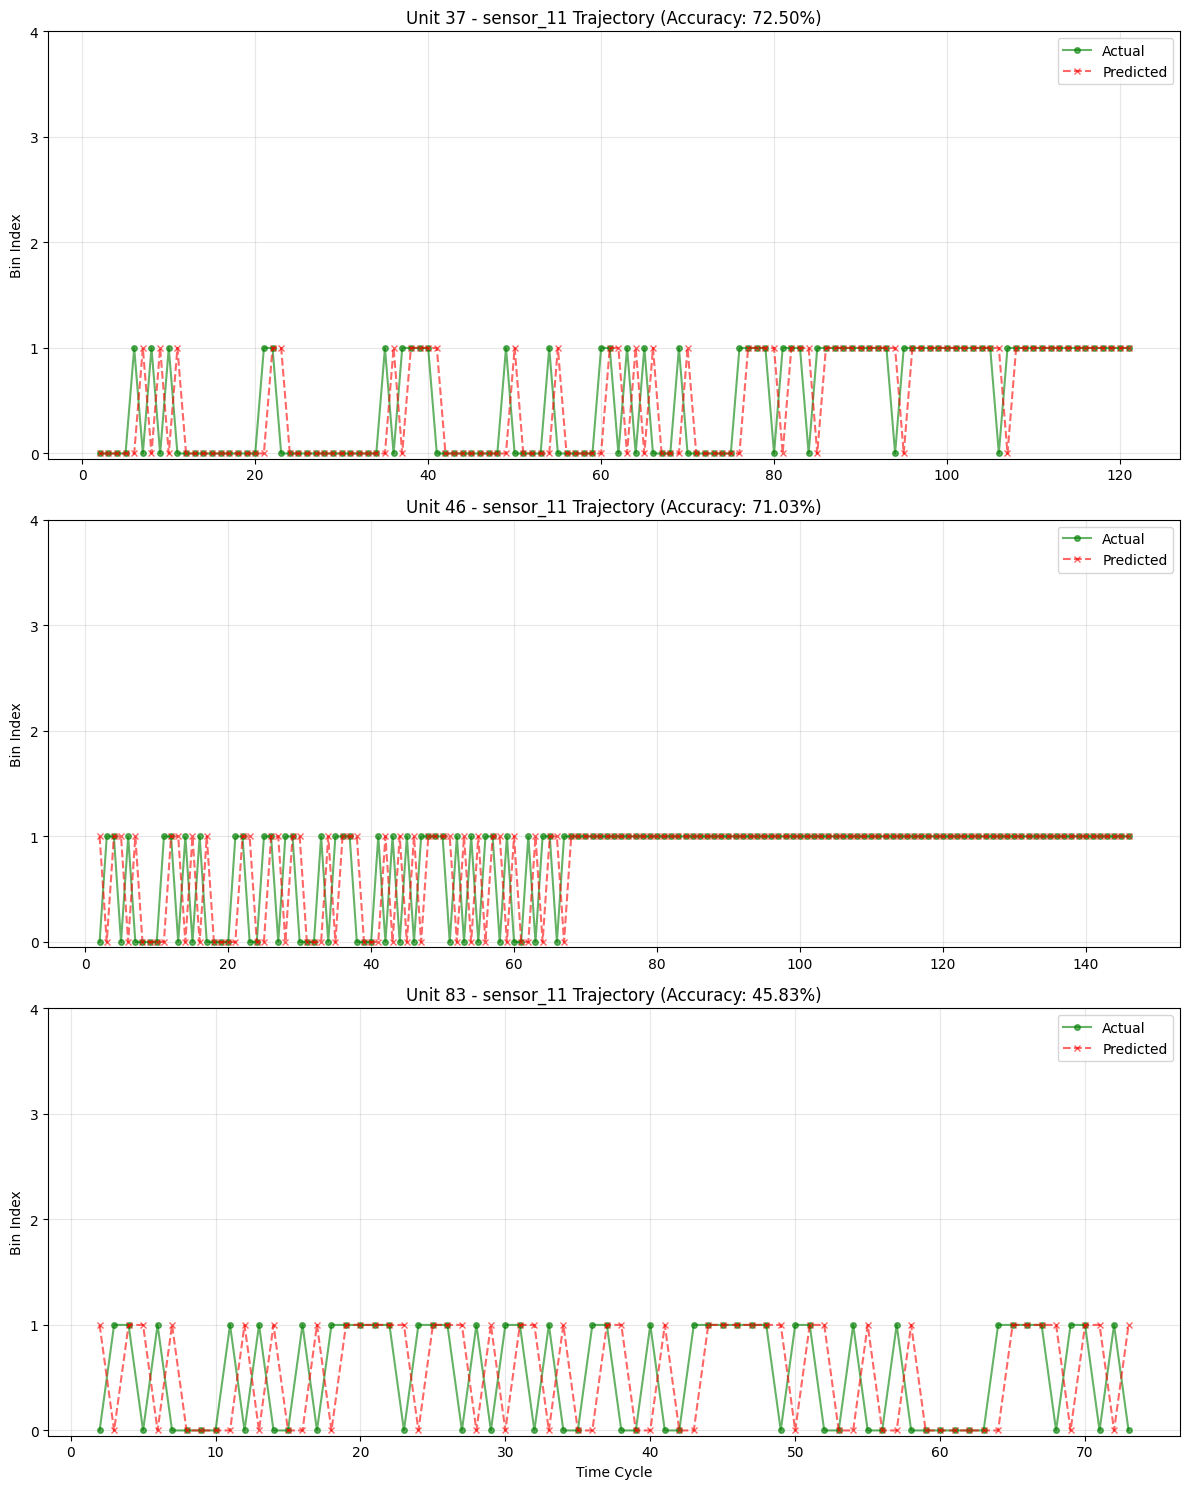

In [20]:
import random
import matplotlib.pyplot as plt
import numpy as np

# 1. Select 3 random units
all_units = test_df['unit_number'].unique()
selected_units = random.sample(list(all_units), 3)
selected_units.sort()

print(f"Selected Test Units for Evaluation: {selected_units}")

# 2. Setup Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 15))
target_sensor = 'sensor_11'

# 3. Iterate and Evaluate
for i, unit_id in enumerate(selected_units):
    unit_data = test_df[test_df['unit_number'] == unit_id].reset_index(drop=True)

    predicted_bins = []
    actual_bins = []
    cycles = []

    # Predict for each time step
    for t_idx in range(len(unit_data) - 1):
        try:
            row_t = unit_data.iloc[t_idx]
            row_t1 = unit_data.iloc[t_idx + 1]

            # Evidence from current time t
            evidence = {}
            for feature in features:
                evidence[(feature, 0)] = int(row_t[feature])

            # Query t+1 using the existing 'infer' object
            query = infer.query(variables=[(target_sensor, 1)], evidence=evidence, show_progress=False)
            pred = np.argmax(query.values)

            predicted_bins.append(pred)
            actual_bins.append(int(row_t1[target_sensor]))
            cycles.append(row_t1['time_cycle'])
        except Exception as e:
            continue

    # Calculate Accuracy
    if len(predicted_bins) > 0:
        accuracy = np.mean(np.array(predicted_bins) == np.array(actual_bins))
    else:
        accuracy = 0.0

    # Plot
    ax = axes[i]
    ax.plot(cycles, actual_bins, 'go-', label='Actual', markersize=4, alpha=0.6)
    ax.plot(cycles, predicted_bins, 'rx--', label='Predicted', markersize=4, alpha=0.6)
    ax.set_title(f"Unit {unit_id} - {target_sensor} Trajectory (Accuracy: {accuracy:.2%})")
    ax.set_ylabel("Bin Index")
    ax.set_yticks(range(5))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

    if i == 2:
        ax.set_xlabel("Time Cycle")

plt.tight_layout()
plt.show()

Starting evaluation on 100 test units... This may take a few minutes.


Evaluating Units:   0%|          | 0/100 [00:00<?, ?it/s]


Evaluation Complete.
Overall Mean Accuracy: 75.92%
Standard Deviation: 14.34%
Best Performing Unit: 11 (Accuracy: 100.00%)
Worst Performing Unit: 75 (Accuracy: 42.53%)


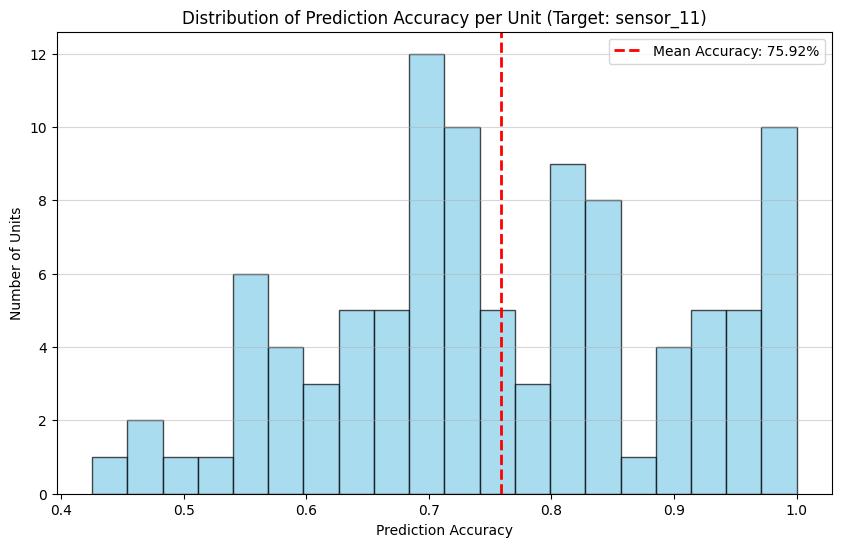

In [21]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np

# Initialize storage for results
unit_accuracies = {}
target_sensor = 'sensor_11'

# Get list of all units
test_units = test_df['unit_number'].unique()

print(f"Starting evaluation on {len(test_units)} test units... This may take a few minutes.")

# Iterate through each unit with progress bar
for unit_id in tqdm(test_units, desc="Evaluating Units"):
    unit_data = test_df[test_df['unit_number'] == unit_id].reset_index(drop=True)

    correct_predictions = 0
    total_predictions = 0

    # Iterate through time steps (t -> t+1)
    # We stop at len-1 because we need t+1 for ground truth
    for t_idx in range(len(unit_data) - 1):
        try:
            row_t = unit_data.iloc[t_idx]
            row_t1 = unit_data.iloc[t_idx + 1]

            # Construct evidence at time t (current state)
            evidence = {}
            for feature in features:
                evidence[(feature, 0)] = int(row_t[feature])

            # Query the network for target sensor at time t+1
            # We are querying the node (target_sensor, 1)
            query = infer.query(variables=[(target_sensor, 1)],
                                evidence=evidence,
                                show_progress=False)

            # Get predicted bin (argmax of probability)
            predicted_bin = np.argmax(query.values)
            actual_bin = int(row_t1[target_sensor])

            if predicted_bin == actual_bin:
                correct_predictions += 1
            total_predictions += 1

        except Exception as e:
            # Skip failed inferences
            continue

    # Calculate accuracy for this unit
    if total_predictions > 0:
        acc = correct_predictions / total_predictions
        unit_accuracies[unit_id] = acc
    else:
        unit_accuracies[unit_id] = 0.0

# Convert to list for analysis
acc_values = list(unit_accuracies.values())

# Statistics
mean_acc = np.mean(acc_values)
std_acc = np.std(acc_values)
max_acc = np.max(acc_values)
min_acc = np.min(acc_values)

best_unit = [u for u, a in unit_accuracies.items() if a == max_acc][0]
worst_unit = [u for u, a in unit_accuracies.items() if a == min_acc][0]

print("\nEvaluation Complete.")
print(f"Overall Mean Accuracy: {mean_acc:.2%}")
print(f"Standard Deviation: {std_acc:.2%}")
print(f"Best Performing Unit: {best_unit} (Accuracy: {max_acc:.2%})")
print(f"Worst Performing Unit: {worst_unit} (Accuracy: {min_acc:.2%})")

# Histogram Plot
plt.figure(figsize=(10, 6))
plt.hist(acc_values, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(mean_acc, color='red', linestyle='dashed', linewidth=2, label=f'Mean Accuracy: {mean_acc:.2%}')
plt.xlabel('Prediction Accuracy')
plt.ylabel('Number of Units')
plt.title(f'Distribution of Prediction Accuracy per Unit (Target: {target_sensor})')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()